In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path =  r"C:\Users\zeyne\Desktop\temiz_veri_seti\birlesik_veri.csv" 

df = pd.read_csv(file_path)

df.head()


,hour,passenger_count,vehicle_type,route_code,stop_code,district,is_outlier,is_peak_hour,mean_passenger_by_route_hour
0,0,2,2,KIRAZLI-BASAKSEHIR/METROKENT,RAYLI,BAGCILAR,0,0,1.532982
1,0,2,2,YENIKAPI - HAVALIMANI,RAYLI,BAHCELIEVLER,0,0,2.980226
2,0,1,2,BAHARIYE-OLIMPIYAT,RAYLI,BAKIRKOY,0,0,1.473945
3,0,9,2,KABATAS-BAGCILAR,RAYLI,BAKIRKOY,1,0,3.376855
4,0,2,2,YENIKAPI - HACIOSMAN,RAYLI,BEYOGLU,0,0,2.826446


1) Kolon Bazlı Genel Histogramlar

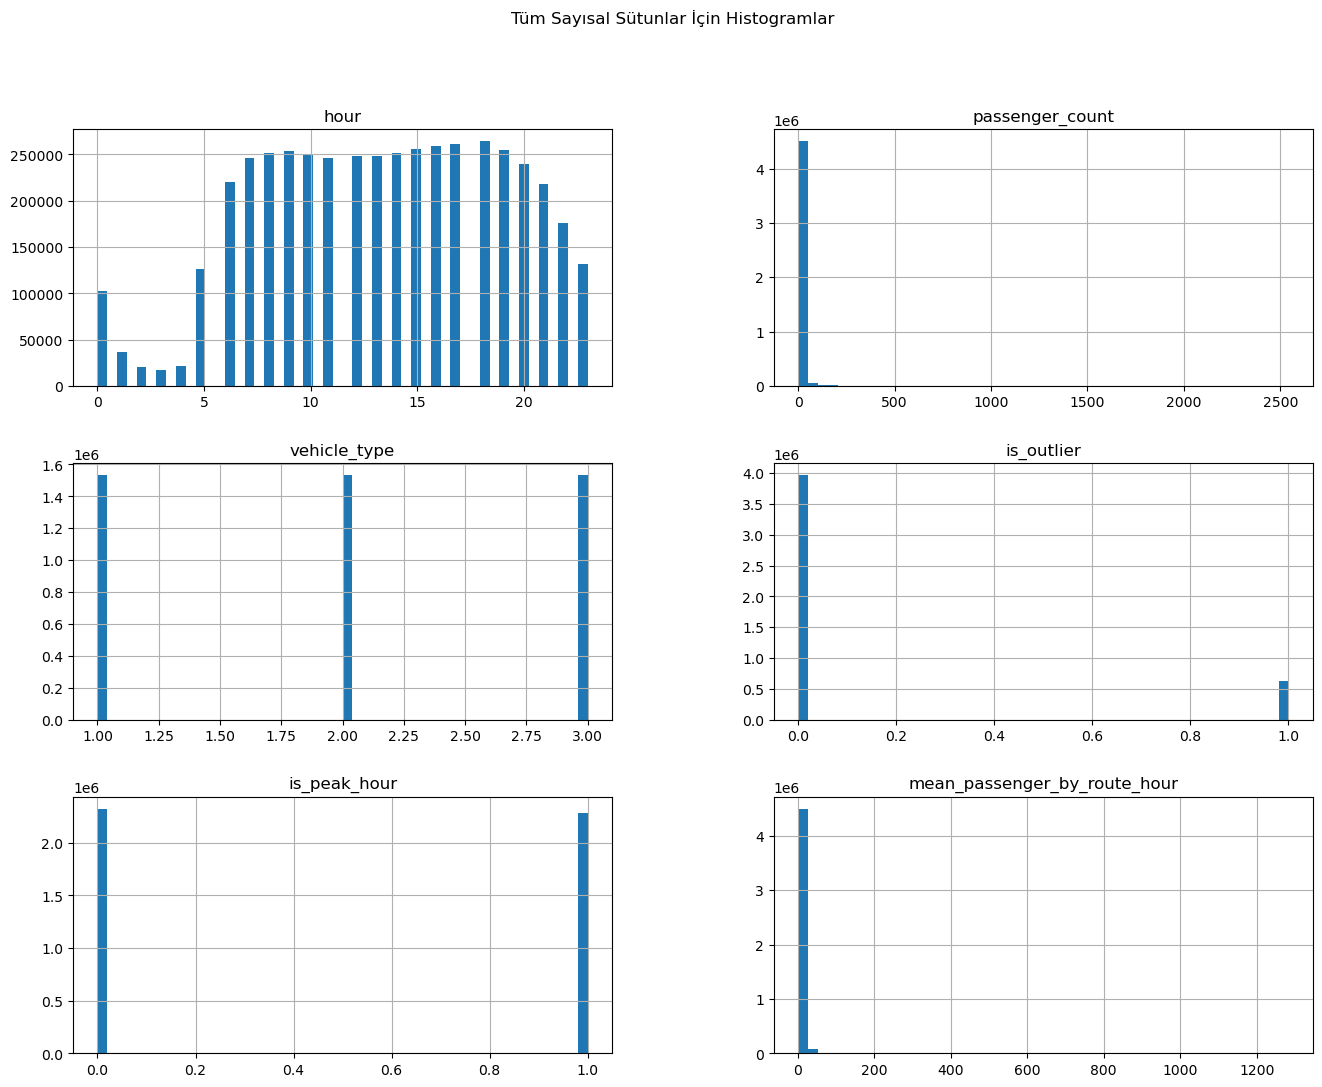

In [2]:
df.hist(figsize=(16,12), bins=50)
plt.suptitle("Tüm Sayısal Sütunlar İçin Histogramlar")
plt.show()


2) Yolcu Sayısı KDE Grafiği

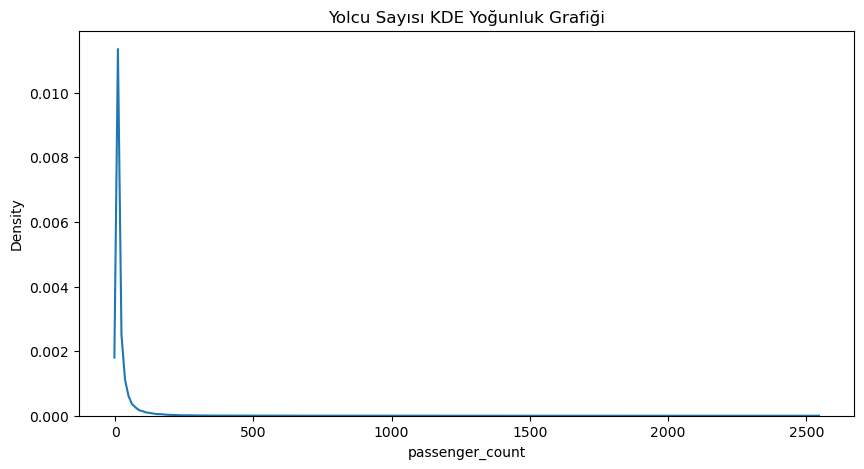

In [3]:
plt.figure(figsize=(10,5))
sns.kdeplot(df['passenger_count'])
plt.title("Yolcu Sayısı KDE Yoğunluk Grafiği")
plt.show()


3) Saat – Ortalama Yolcu Dağılımı

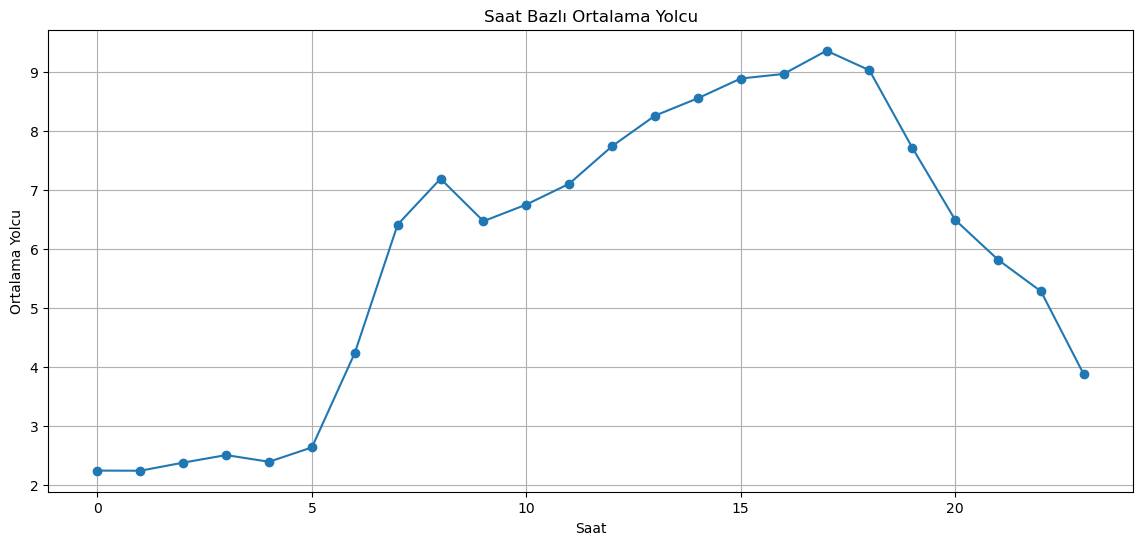

In [4]:
hour_mean = df.groupby("hour")["passenger_count"].mean()

plt.figure(figsize=(14,6))
plt.plot(hour_mean.index, hour_mean.values, marker="o")
plt.title("Saat Bazlı Ortalama Yolcu")
plt.xlabel("Saat")
plt.ylabel("Ortalama Yolcu")
plt.grid()
plt.show()


4) Peak Hour – Yolcu Sayısı Karşılaştırma

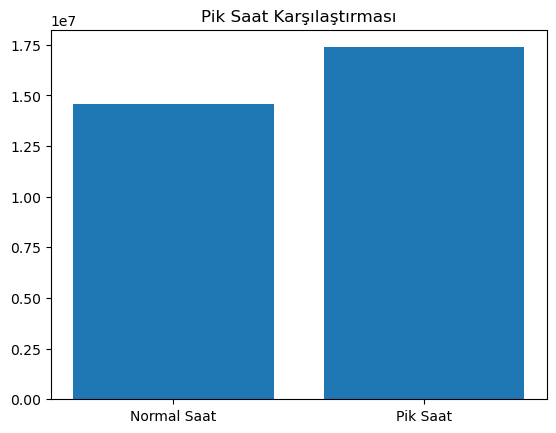

In [5]:
peak = df.groupby("is_peak_hour")["passenger_count"].sum()

plt.bar(["Normal Saat", "Pik Saat"], peak.values)
plt.title("Pik Saat Karşılaştırması")
plt.show()


5) Ulaşım Türü – Ortalama Yolcu Ulaşım Türü – Ortalama Yolcu

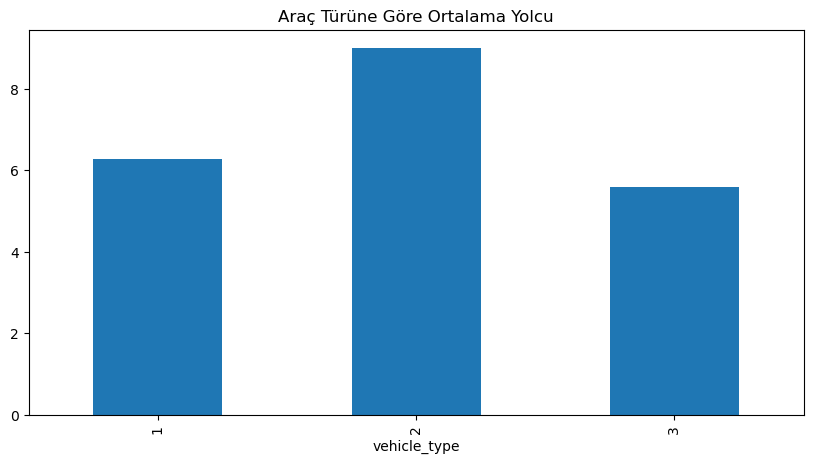

In [6]:
vt_mean = df.groupby("vehicle_type")["passenger_count"].mean()

plt.figure(figsize=(10,5))
vt_mean.plot(kind="bar")
plt.title("Araç Türüne Göre Ortalama Yolcu")
plt.show()


 6) District Bazlı Kutu Grafiği (Boxplot)

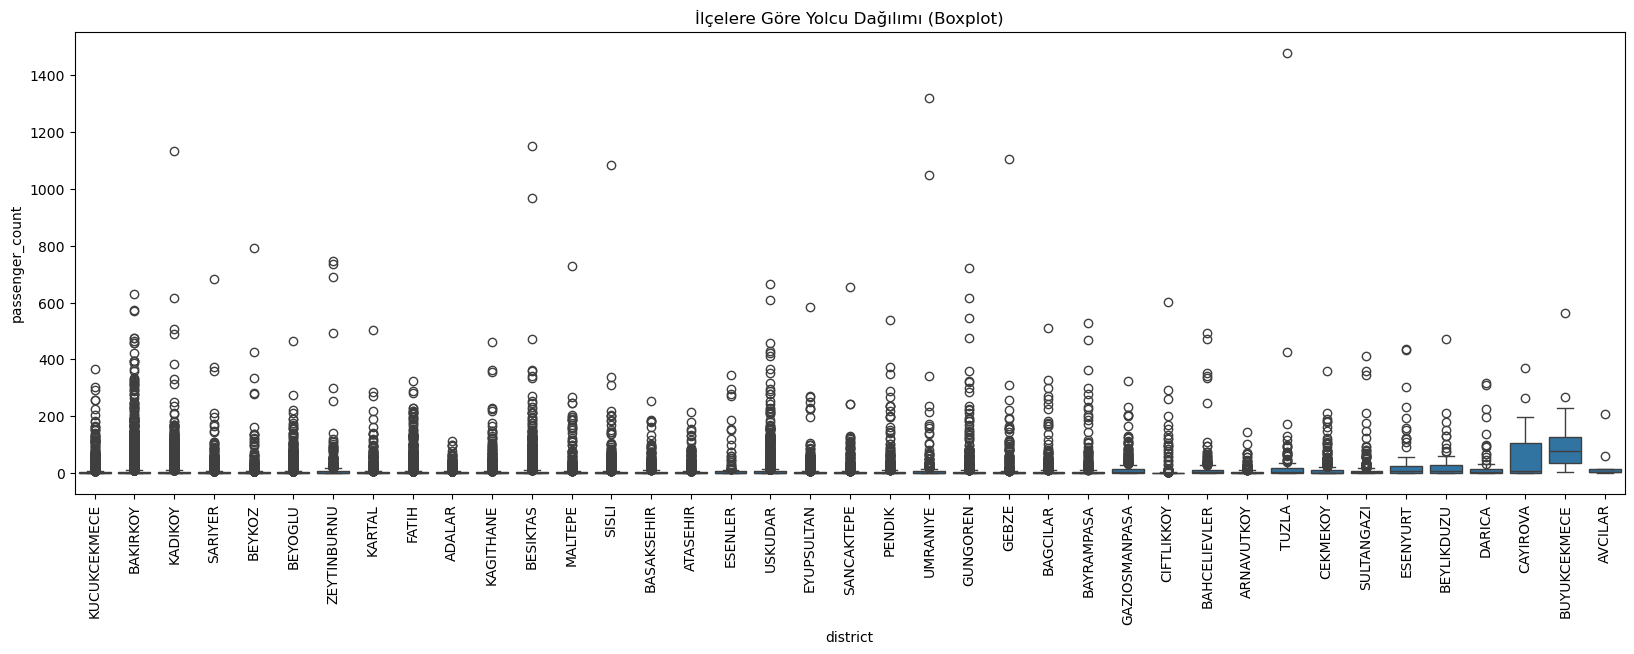

In [7]:
plt.figure(figsize=(20,6))
sns.boxplot(x="district", y="passenger_count", data=df.sample(100000))
plt.xticks(rotation=90)
plt.title("İlçelere Göre Yolcu Dağılımı (Boxplot)")
plt.show()


7) Vehicle Type – Hour Heatmap

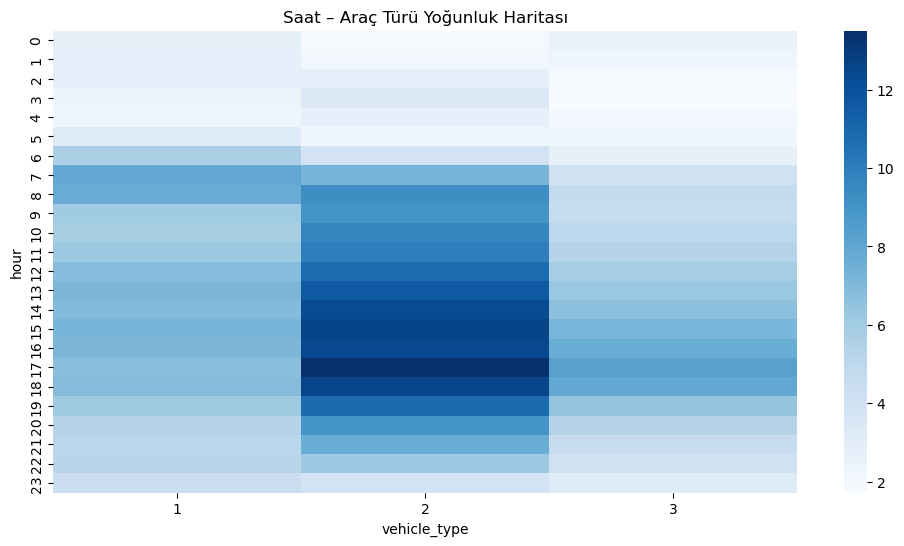

In [8]:
pivot = df.pivot_table(values="passenger_count",
                       index="hour",
                       columns="vehicle_type",
                       aggfunc="mean")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="Blues")
plt.title("Saat – Araç Türü Yoğunluk Haritası")
plt.show()


8) District – Vehicle Type Heatmap

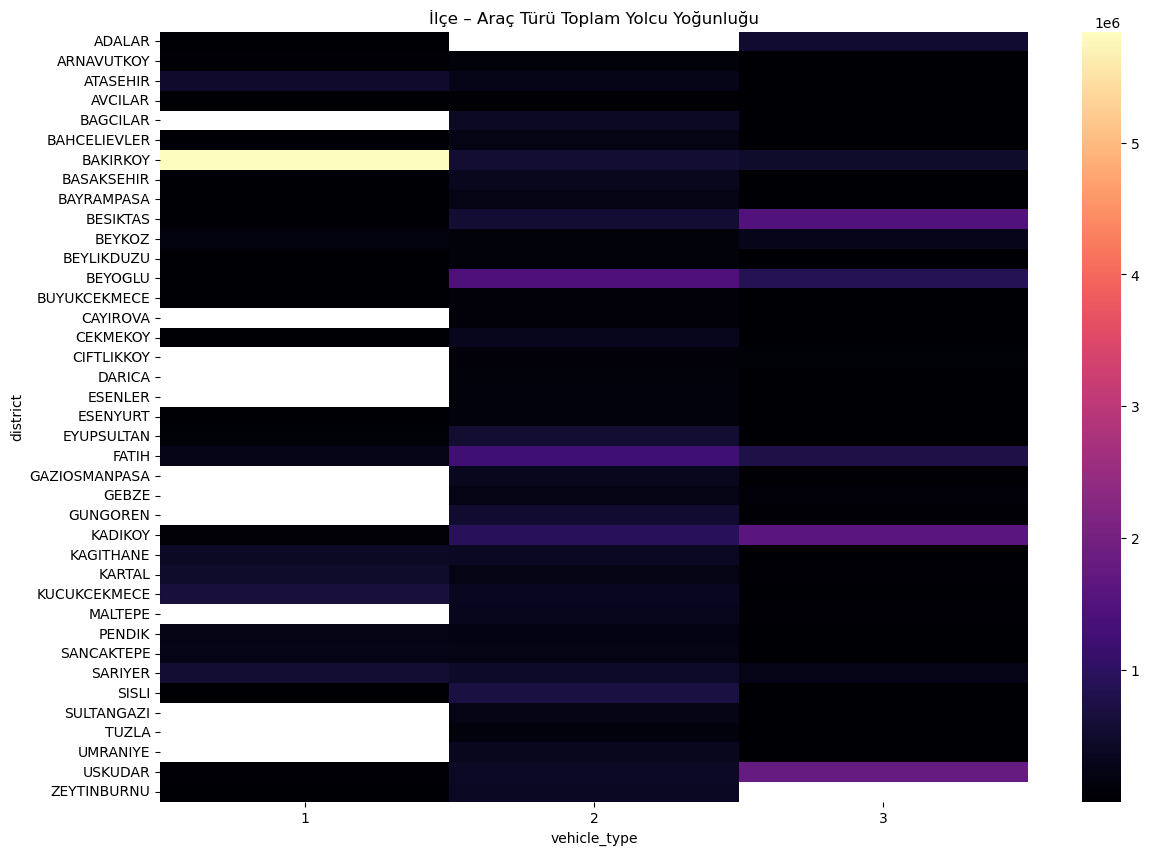

In [9]:
pivot2 = df.pivot_table(values="passenger_count",
                        index="district",
                        columns="vehicle_type",
                        aggfunc="sum")

plt.figure(figsize=(14,10))
sns.heatmap(pivot2, cmap="magma")
plt.title("İlçe – Araç Türü Toplam Yolcu Yoğunluğu")
plt.show()


 9) Route Code – Yolcu Sayısı (Top 30)

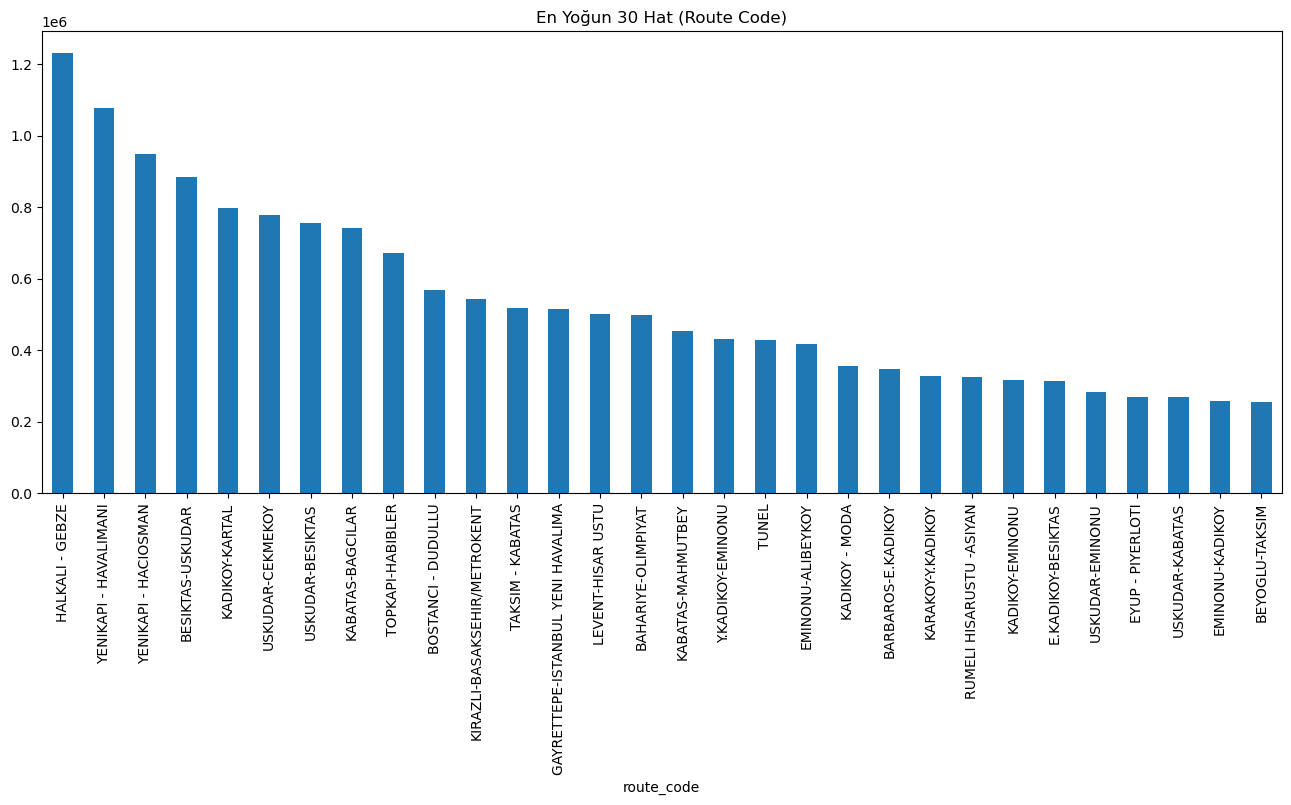

In [10]:
top_routes = df.groupby("route_code")["passenger_count"].sum().sort_values(ascending=False).head(30)

plt.figure(figsize=(16,6))
top_routes.plot(kind="bar")
plt.title("En Yoğun 30 Hat (Route Code)")
plt.xticks(rotation=90)
plt.show()


10) Stop Code – Yolcu Dağılımı

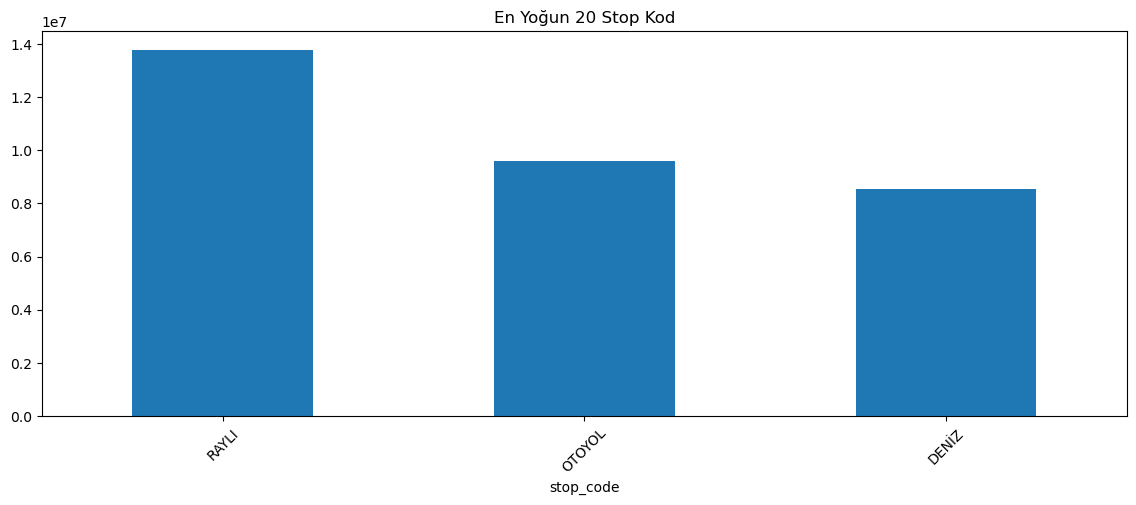

In [11]:
stop_sum = df.groupby("stop_code")["passenger_count"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,5))
stop_sum.plot(kind="bar")
plt.title("En Yoğun 20 Stop Kod")
plt.xticks(rotation=45)
plt.show()


11) Correlation Heatmap

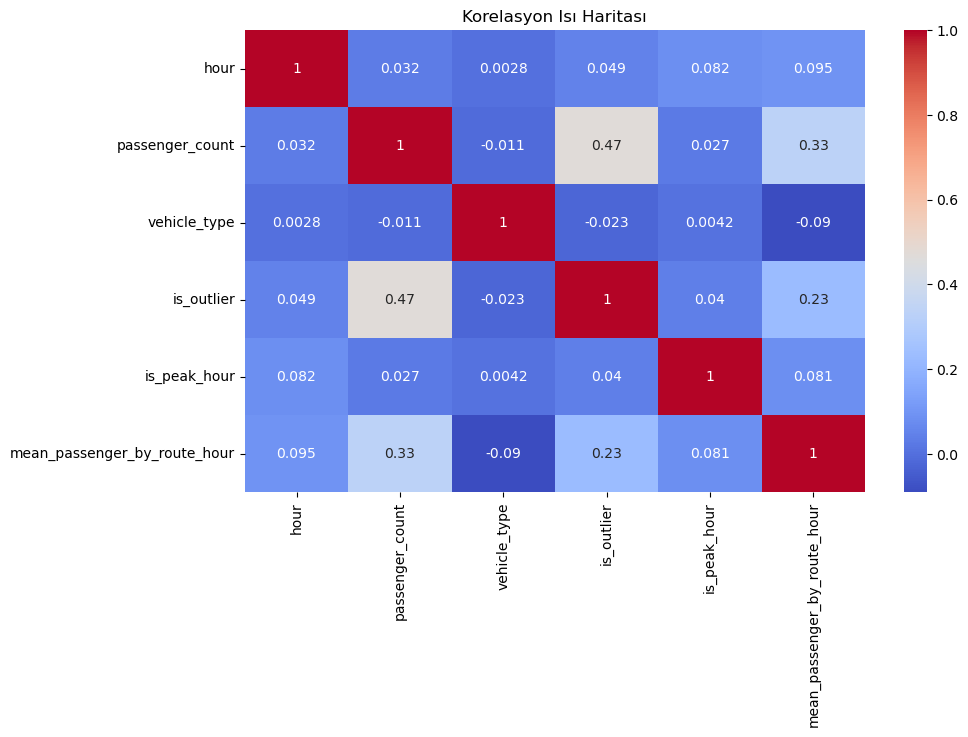

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Korelasyon Isı Haritası")
plt.show()


12) Vehicle Type – District Boxplot

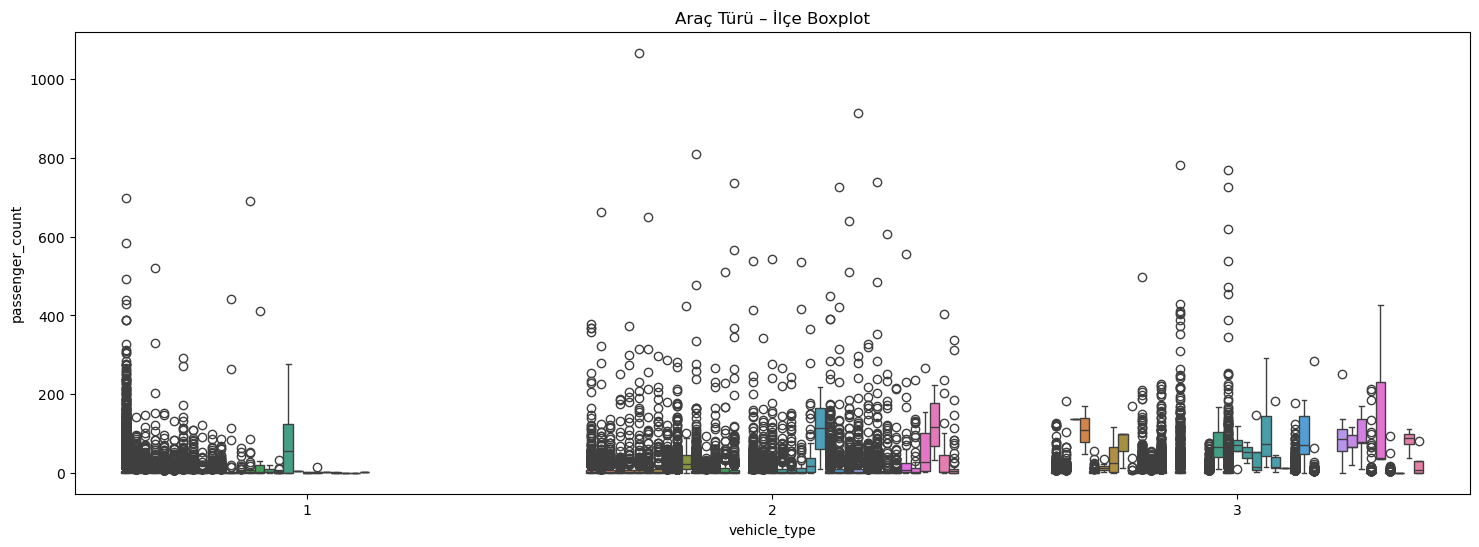

In [13]:
plt.figure(figsize=(18,6))
sns.boxplot(x="vehicle_type", y="passenger_count", hue="district", data=df.sample(80000))
plt.title("Araç Türü – İlçe Boxplot")
plt.legend([],[], frameon=False)
plt.show()


13) Saat – Araç Türü – İlçe Kombinasyonu (3D Heatmap)

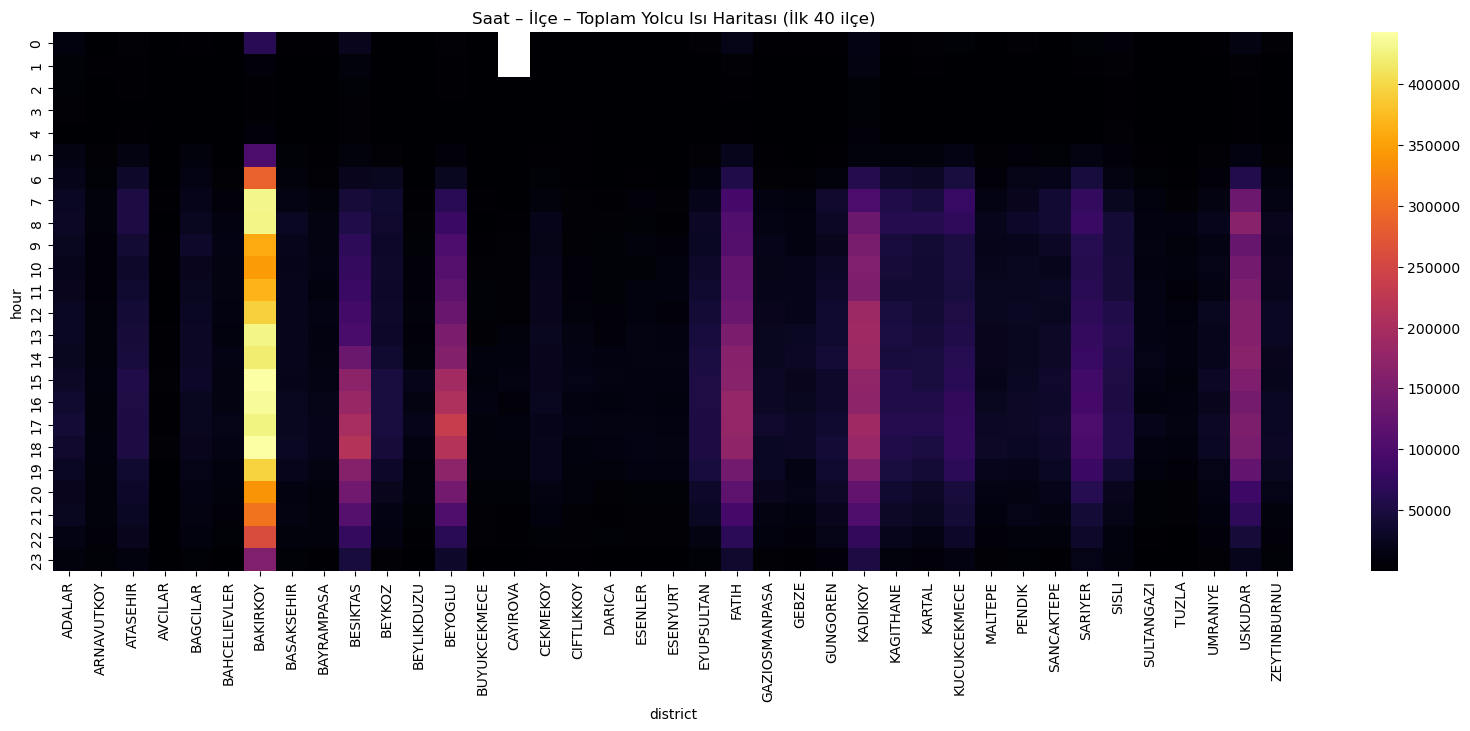

In [14]:
pivot = df.pivot_table(values="passenger_count",
                       index="hour",
                       columns="district",
                       aggfunc="sum")

plt.figure(figsize=(20,7))
sns.heatmap(pivot.iloc[:, :40], cmap="inferno")
plt.title("Saat – İlçe – Toplam Yolcu Isı Haritası (İlk 40 ilçe)")
plt.show()


14) En Çok Yolcu Taşıyan İlk 50 Hat (Toplam Yolcu Sayısına Göre)

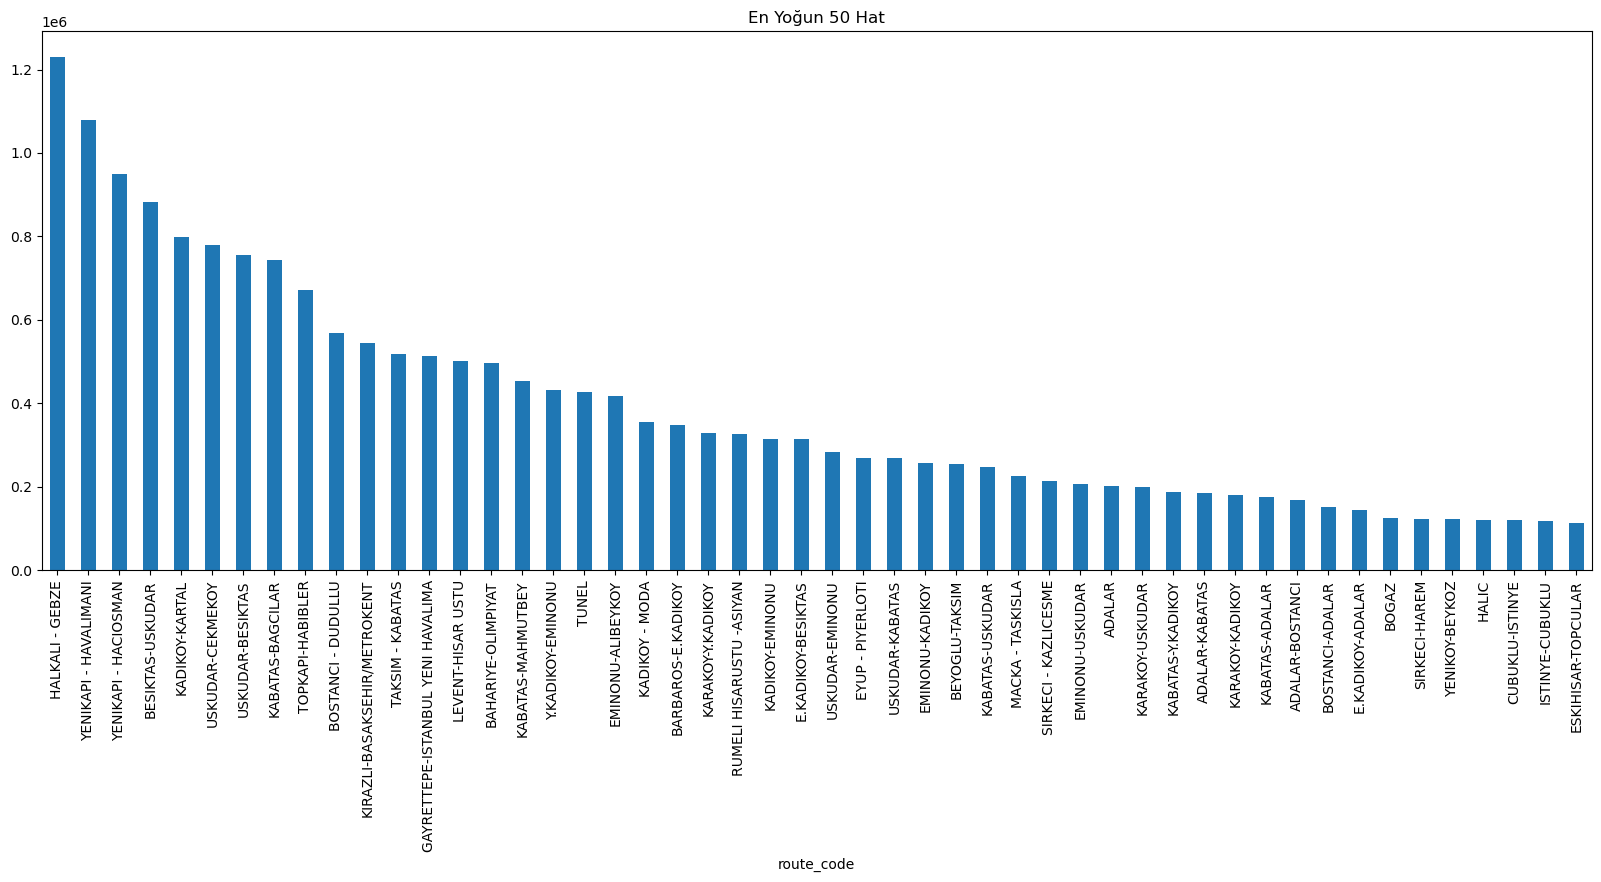

In [15]:
routes = df.groupby("route_code")["passenger_count"].sum().sort_values(ascending=False).head(50)

plt.figure(figsize=(20,7))
routes.plot(kind="bar")
plt.title("En Yoğun 50 Hat")
plt.xticks(rotation=90)
plt.show()


15) Yol Tipine Göre (stop_code) Yoğun Saat Grafiği

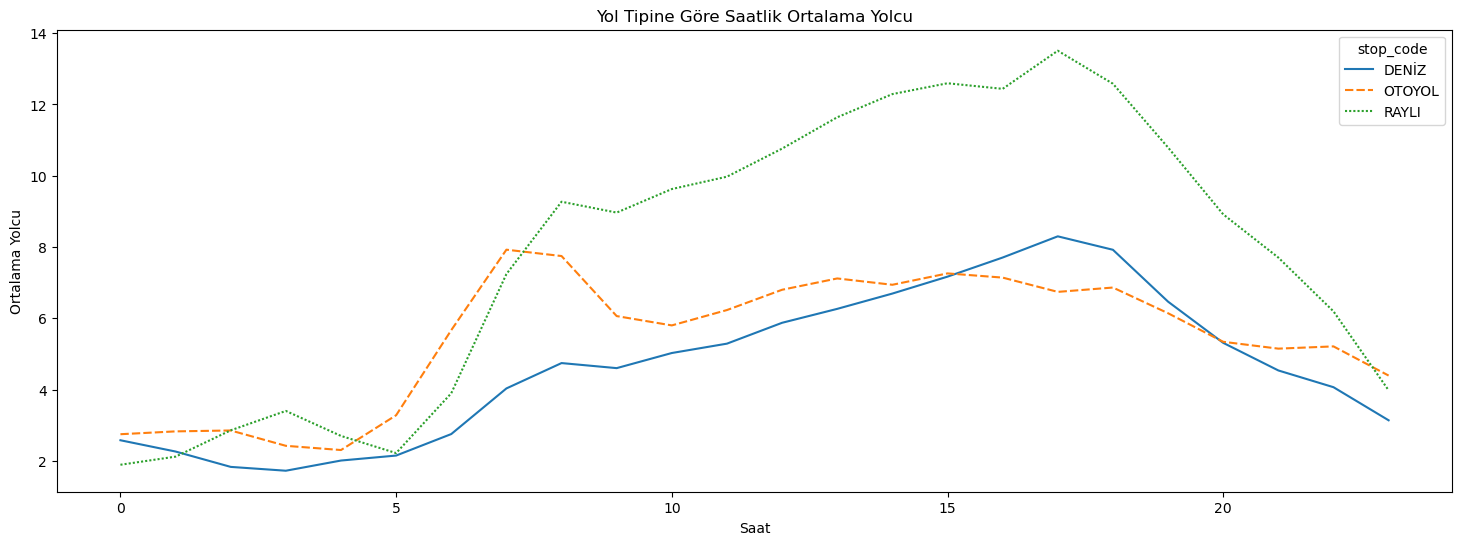

In [16]:
pivot = df.pivot_table(values="passenger_count",
                       index="hour",
                       columns="stop_code",
                       aggfunc="mean")

plt.figure(figsize=(18,6))
sns.lineplot(data=pivot)
plt.title("Yol Tipine Göre Saatlik Ortalama Yolcu")
plt.xlabel("Saat")
plt.ylabel("Ortalama Yolcu")
plt.show()


16) İlçelere Göre Kayıt Sayısı Dağılımı

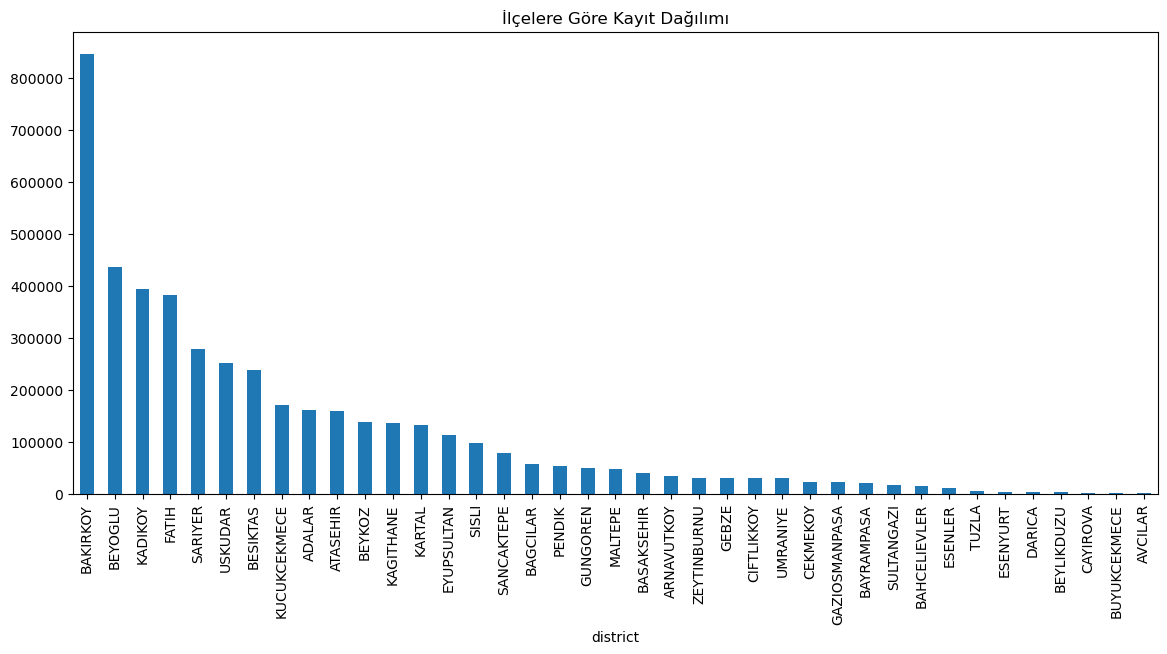

In [17]:
plt.figure(figsize=(14,6))
df['district'].value_counts().plot(kind="bar")
plt.title("İlçelere Göre Kayıt Dağılımı")
plt.xticks(rotation=90)
plt.show()


17) Peak Hour – Vehicle Type Karşılaştırması

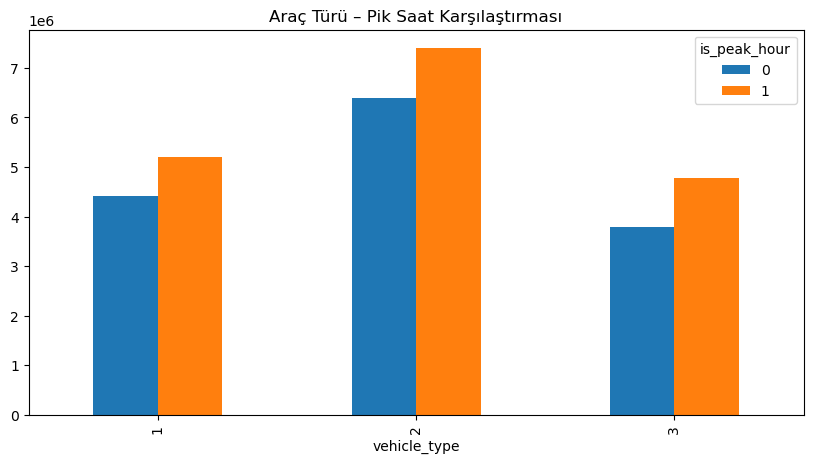

In [18]:
peak = df.groupby(["vehicle_type","is_peak_hour"])["passenger_count"].sum().unstack()

peak.plot(kind="bar", figsize=(10,5))
plt.title("Araç Türü – Pik Saat Karşılaştırması")
plt.show()


18) En Yoğun 30 İlçe İçin Hat Dağılımı (Countplot)

In [ ]:
top30 = df['district'].value_counts().head(30).index
sample = df[df['district'].isin(top30)].sample(200000)

plt.figure(figsize=(20,8))
sns.countplot(data=sample, x="district", hue="vehicle_type")
plt.xticks(rotation=90)
plt.title("En Yoğun 30 İlçe – Araç Türü Dağılımı")
plt.show()


19) Scatterplot – Saat & Yolcu

In [ ]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df.sample(30000), x="hour", y="passenger_count")
plt.title("Saat – Yolcu Scatter")
plt.show()


20) Kategori Grafiklerinin Otomatik Üretimi (Tüm kategoriler)

In [ ]:
cat_cols = ["vehicle_type", "district", "stop_code", "route_code"]

for col in cat_cols:
    plt.figure(figsize=(14,5))
    df[col].value_counts().head(20).plot(kind="bar")
    plt.title(f"{col} İlk 20 Kategori Dağılımı")
    plt.xticks(rotation=90)
    plt.show()


21) Line Chart – Her Araç Türü İçin Saatlik Yoğunluk

In [ ]:
df2 = df.groupby(["vehicle_type","hour"])["passenger_count"].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=df2, x="hour", y="passenger_count", hue="vehicle_type")
plt.title("Araç Türüne Göre Saatlik Ortalama Yolcu")
plt.show()


22) En Yoğun 15 Hatın Yoğunluk Saat Profili

In [ ]:
top15_routes = df['route_code'].value_counts().head(15).index
sample = df[df["route_code"].isin(top15_routes)]

pivot = sample.pivot_table(values="passenger_count",
                           index="hour",
                           columns="route_code",
                           aggfunc="mean")

plt.figure(figsize=(20,7))
sns.lineplot(data=pivot)
plt.title("En Yoğun 15 Hat – Saatlik Yoğunluk")
plt.show()
